In [1]:
pip install --pre pycen==0.1.0a4

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pycen
import numpy as np
import matplotlib.pyplot as plt
from pycen import explore, acquire
import geopandas as gpd
import pandas as pd

In [3]:
explore.browse(year=2013, dataset='acs5').show()

In [4]:
vars_to_download = {
    "B08301_018E": "bikers",
    "B08301_001E": "workers_total"}

PLACE = "Berkeley, California, USA"
YEARS = [2013, 2014, 2015, 2016, 2017, 2018, 2019]
DATASET = "acs5"

In [23]:
gdf = acquire.get_censhp(
      variables=vars_to_download,
      geography='tract',
      state='CA',
      county='Alameda',
      year=2013,
      dataset='acs5',
      add_area=True,               # calculate area and adds to geodataframe
      cache=False                # cache by default, can disable
      #cache_dir="./pycen_cache"  # default cache directo"ry, can customize
  )
gdf.head()
gdf=gdf.sort_values(by='tract')
gdf=gdf.set_index('tract')

Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)

Fetching data...
  Product: acs5 (2013)
  Geography: Tract
  Variables: 2


Downloading: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]


Fetching boundaries...
Merging data...

Done!


In [24]:
gdf["pctbikers"]=gdf["bikers"]/gdf["workers_total"]*100
#print(gdf)

In [25]:
ninet = acquire.get_censhp(
      variables=vars_to_download,
      geography='tract',
      state='CA',
      county='Alameda',
      year=2019,
      dataset='acs5',
      add_area=True,               # calculate area and adds to geodataframe
      cache=False                # cache by default, can disable
      #cache_dir="./pycen_cache"  # default cache directory, can customize
  )
ninet.head()
ninet=ninet.sort_values(by='tract')
ninet=ninet.set_index('tract')

Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)

Fetching data...
  Product: acs5 (2019)
  Geography: Tract
  Variables: 2


Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


Fetching boundaries...
Merging data...

Done!


In [26]:
ninet["pctbikers"]=ninet["bikers"]/ninet["workers_total"]*100
#print(ninet)

In [27]:
change=ninet.copy()
print(ninet["pctbikers"]-gdf["pctbikers"])
change["% Change in Ridership between 2013-2019"]=(ninet["pctbikers"]-gdf["pctbikers"])
#print(ninet["pctbikers"])
#print(gdf["pctbikers"])
#print(ninet["pctbikers"]-gdf["pctbikers"])
#print(change)
#print(gdf.loc['423500'])
#print(ninet.loc['423500'])
#print(change.loc['423500'])

tract
400100    -1.919123
400200     1.558666
400300     3.280267
400400    -6.059178
400500     0.193103
            ...    
451704     0.155772
981900    29.629630
982000     0.000000
983200     0.000000
990000          NaN
Name: pctbikers, Length: 361, dtype: float64


In [ ]:
#CHANGE IN RIDERSHIP set (indexted by census tract)
#change["% Change in Ridership between 2013-2019"]

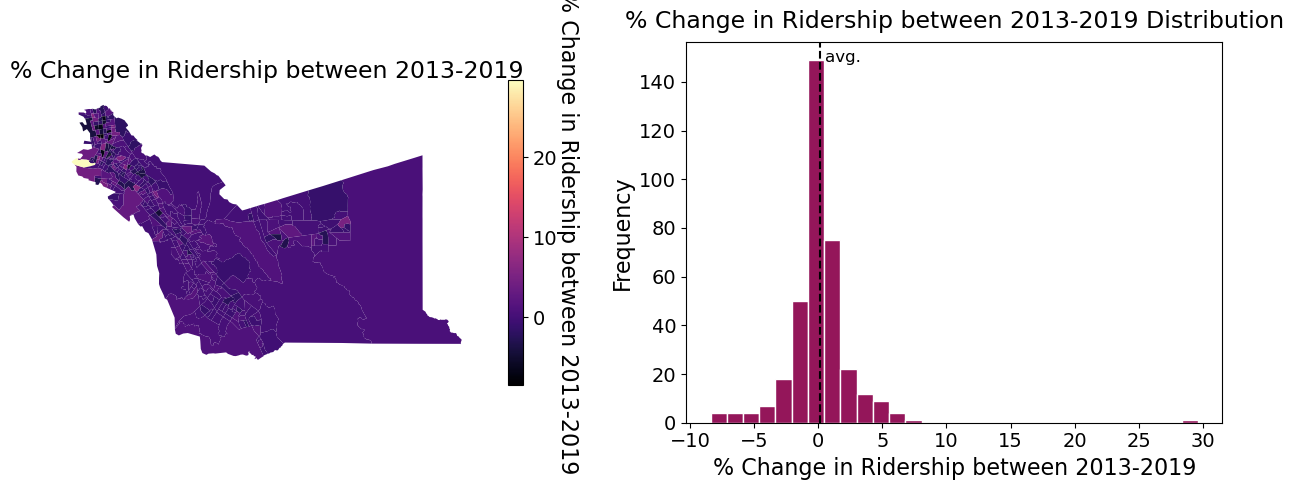

In [28]:
acquire.quick_viz(change, "% Change in Ridership between 2013-2019")

In [30]:
highextreme=change[change["% Change in Ridership between 2013-2019"]>5]
#print(highextreme)
highextremearray=highextreme.index.values.astype(int)
print(highextremearray)

[401000 402400 402500 405100 406400 408800 420500 981900]


In [31]:
tracts_by_year=[]
for year in YEARS:
    gdf1 = acquire.get_censhp(
        variables=vars_to_download,
        geography="tract",
        county='Alameda',
        state="CA",
        year=year,
        dataset=DATASET,
        add_area=True
    )
    gdf1.replace(-666666666, np.nan, inplace=True) 
    gdf1["year"] = year
    gdf1["pct_bike"] = (gdf1["bikers"] / gdf1["workers_total"]) * 100
    highextremetracts = gdf1[gdf1["tract"].isin(highextremearray)]
    tracts_by_year.append(highextremetracts.to_crs("EPSG:4326"))

Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)
Loading from cache: pycen_cache/api/acs5_2013_tract_06_001_8a882376875acefe.csv
Loading boundaries from cache...
Merging data...
Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)
Loading from cache: pycen_cache/api/acs5_2014_tract_06_001_7159ac38b38b7ba9.csv
Loading boundaries from cache...
Merging data...
Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)
Loading from cache: pycen_cache/api/acs5_2015_tract_06_001_1166484792d33488.csv
Loading boundaries from cache...
Merging data...
Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)
Loading from cache: pycen_cache/api/acs5_2016_tract_06_001_0809305c4bdaaace.csv
Loading boundaries from cache...
Merging data...
Resolving geography...
  State: California (CA, FIPS: 06)
  County: Alameda County (FIPS: 001)
Loading f

In [32]:
tracts = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")
print(tracts[["tract", "pct_bike", "year"]].groupby("tract").head())

     tract   pct_bike  year
0   402400   0.800000  2013
1   408800   0.000000  2013
2   420500   2.460630  2013
3   402500   0.719424  2013
4   405100   3.033528  2013
5   406400   0.600601  2013
6   981900   0.000000  2013
7   401000   2.792065  2013
8   420500   4.240283  2014
9   402500   1.929825  2014
10  405100   3.284487  2014
11  406400   0.817439  2014
12  401000   5.126354  2014
13  402400   2.837573  2014
14  408800   0.000000  2014
15  981900   0.000000  2014
16  408800   0.000000  2015
17  405100   3.191489  2015
18  402500   1.818182  2015
19  420500   6.490179  2015
20  406400   3.740648  2015
21  981900   0.000000  2015
22  401000   5.051112  2015
23  402400   2.225755  2015
24  402400   8.950844  2016
25  405100   3.026316  2016
26  406400   3.861518  2016
27  402500   1.801802  2016
28  420500   5.047868  2016
29  401000   6.590017  2016
30  981900  32.000000  2016
31  408800   0.000000  2016
32  406400   4.572098  2017
33  402500   2.698145  2017
34  420500   5.68965

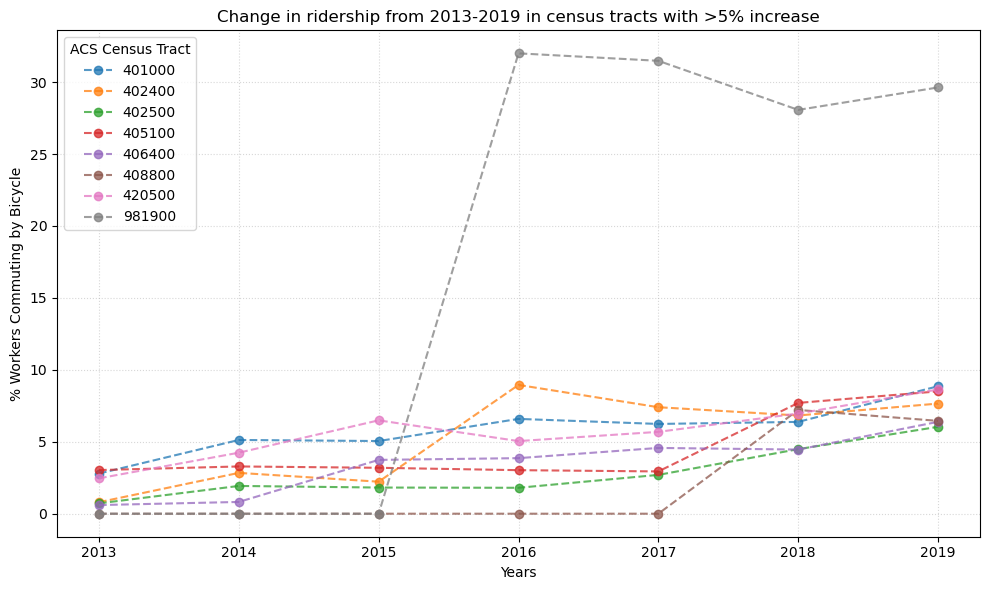

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
for tract, group in tracts.groupby("tract"):
    group = group.dropna(subset=["year", "pct_bike"])
    ax.plot(
        YEARS,
        group["pct_bike"],
        alpha=0.75,
        label=tract,
        linestyle='--', 
        marker='o'
    )
ax.set_xlabel("Years")
ax.set_ylabel("% Workers Commuting by Bicycle")
ax.set_title("Change in ridership from 2013-2019 in census tracts with >5% increase")
ax.legend(title="ACS Census Tract")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()